# Face Generation with GMM and PCA

In this project, Gaussian Mixture Models (GMM) and Principal Component Analysis (PCA) are used together to generate synthetic face images.

## Objective
The goal is to model the distribution of face images and generate new samples from a lower-dimensional latent space.

## Approach
Since GMM can be computationally expensive for high-dimensional image data, PCA is first applied to reduce dimensionality.  
The reduced representations are then used to train a GMM.

The overall pipeline is:

**face images → PCA projection → lower-dimensional representation → GMM training → random sampling → inverse PCA → generated face images**

## Methods
- Image preprocessing
- Dimensionality reduction with PCA
- Density modeling with Gaussian Mixture Models
- Sampling and image reconstruction

## Outcome
This project demonstrates how PCA can make generative modeling more efficient and how GMM can be used to synthesize new face images from learned data distributions.

In [26]:
import platform, socket, getpass
from time import time
from datetime import datetime
import random
signature=[socket.gethostbyname(socket.gethostname()),
           getpass.getuser(),
           datetime.now(),
           random.random()]
print(signature) 

['127.0.0.1', 'yaseminaleyna', datetime.datetime(2026, 3, 26, 1, 45, 49, 80099), 0.02408867231255052]


In [27]:
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
sn.set(style='whitegrid')
from sklearn.mixture import GaussianMixture as GMM

### Load image data

In [28]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=500)
print(faces.target_names)
print(faces.images.shape)

['George W Bush']
(530, 62, 47)


In [29]:
#what is N ?
N=faces.images.shape[0]
N

530

In [30]:
#what is M?
M=faces.images.shape[1]*faces.images.shape[2]
M

2914

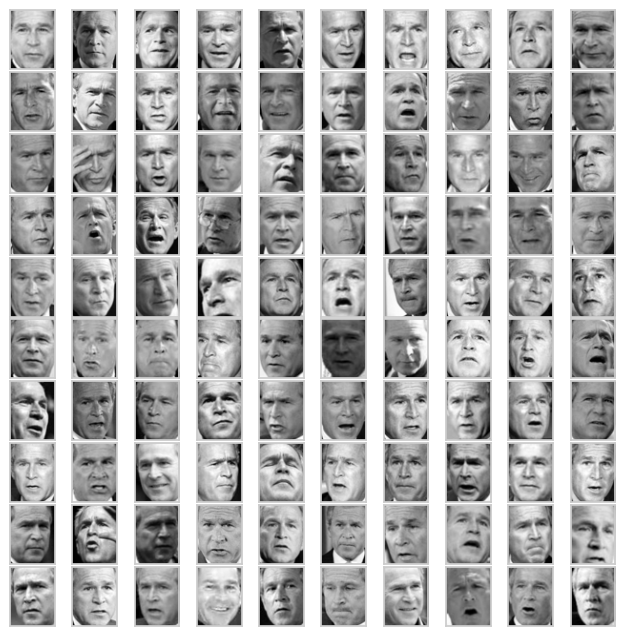

In [31]:
def plot_faces(data):
    fig, ax = plt.subplots(10, 10, figsize=(8, 8), subplot_kw=dict(xticks=[], yticks=[]))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    for i, axi in enumerate(ax.flat):
        im = axi.imshow(data[i], cmap='gray')
plot_faces(faces.images)

We have N images, and each image has M pixels <br>
N = 530  <  M = 2914 <br>
the number of samples is smaller than the dimension <br>
We will use dimension reduction to reduce the number of features

### Apply PCA to images

In [32]:
# apply PCA to images
from sklearn.decomposition import PCA

# flatten images: (N, H, W) -> (N, M)
X = faces.images.reshape(N, -1)

# PCA
pca = PCA(n_components=120, whiten=True, random_state=0)
data = pca.fit_transform(X)

In [33]:
#check the shape of data
data.shape

(530, 120)

In [34]:
#obtain the value of cumulative explained variance ratio when "n_components"=120

cumulative_variance = pca.explained_variance_ratio_.sum()
cumulative_variance

np.float32(0.9459154)

### Fit GMM 
Afer PCA transform, the number of features is changed from 2914 (62*47) to 120 <br>
N = 530,  data.shape[1] = 120 <br>
Now, we fit many GMM to `data` with different number of components <br>
We will select the best one based on AIC

In [35]:
#fit GMM with n_components in the range of 1 to 100 with step 10
n_components = np.arange(1, 100, 10)
# your code:
from sklearn.mixture import GaussianMixture
gmms = [GaussianMixture(n_components=n,
                        covariance_type="diag",
                        reg_covar=1e-3,
                        random_state=0).fit(data)
        for n in n_components]

Overall, the curve keeps going up: something is weird.

It looks like when n_components= ?? AIC reaches the minimum. <br>

In [36]:
# write code to find the best n_components
aics = [gmm.aic(data) for gmm in gmms]
best_n = n_components[np.argmin(aics)]
# fit GMM using the best n_components
gmm = GaussianMixture(n_components=best_n,
                      covariance_type="diag",
                      reg_covar=1e-3,
                      random_state=0)
gmm.fit(data)
print(gmm.converged_)

True


Draw 100 new samples from GMM (gmm) <br>
The new data samples are in the 120-dimensional projected space

In [37]:
#generate data_new from the gmm
data_new, _ = gmm.sample(100)
data_new.shape

(100, 120)

Finally, we can transform the 100 samples back to the original space (pca inverse) <br>
and plot some of the images in the original space <br>

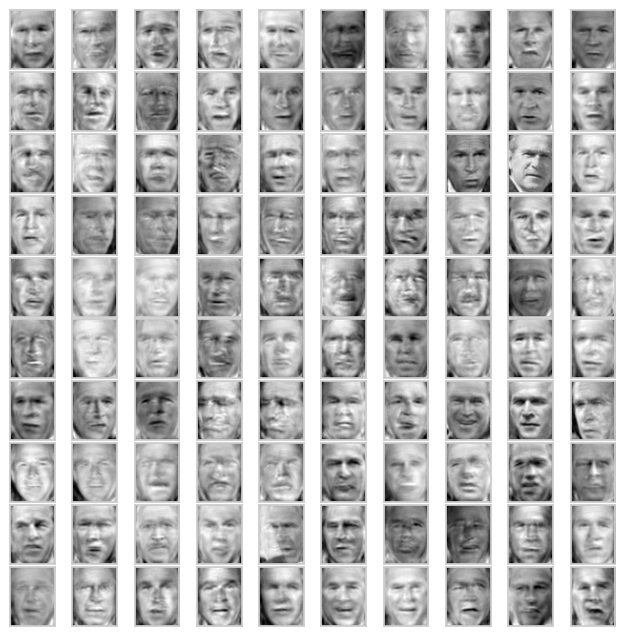

In [38]:
# obtain faces_new by applying inverse pca on data_new
faces_new = pca.inverse_transform(data_new)
plot_faces(faces_new.reshape(-1,62, 47))

### Repeat the above process using more data

In [39]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=50)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Jacques Chirac' 'Jean Chretien'
 'John Ashcroft' 'Junichiro Koizumi' 'Serena Williams' 'Tony Blair']
(1560, 62, 47)


In [40]:
N = faces.images.shape[0]
print(N)

1560


In [41]:
#check the input dimension 
M = faces.images.shape[1] * faces.images.shape[2]
print(M)

2914


We have N images, and each iamge has M pixels  <br>
N = 1560 and M = 2914 : N < M  <br>
We will use dimension reduction to reduce the number of features from 2914 to 120 <br>

In [42]:
# apply PCA to images
from sklearn.decomposition import PCA

# flatten images
X = faces.images.reshape(N, -1)

# apply PCA
pca = PCA(n_components=120, whiten=True, random_state=0)
data = pca.fit_transform(X)

In [43]:
#check the shape of data
data.shape

(1560, 120)

In [44]:
#check the value of cumulative explained variance ratio
cumulative_variance = pca.explained_variance_ratio_.sum()
print(cumulative_variance)

0.9185547


Now, we fit many GMMs to the transformed `data` with different number of components   <br>
We will select the best one based on AIC

In [45]:
#fit GMM with n_components in the range of 1 to 200 with the step of 10
n_components = np.arange(1, 201, 10)
X = data.astype(np.float64)

gmms = [GaussianMixture(n_components=n,
                        covariance_type="diag",
                        reg_covar=1e-3,
                        random_state=0).fit(X)
        for n in n_components]

Now, we have a U-haped curve, nice. (again, you may get a different curve) <br>
It appears that AIC is miminized around 60 components. <br>

In [46]:
aic_values = [gmm.aic(X) for gmm in gmms]

#index of minimum AIC
min_index = np.argmin(aic_values)

best_n = n_components[min_index]
best_n

np.int64(191)

quickly fit GMM with n_components=?? (when AIC is minimum) to the `data` and confirm that it has converged:

In [47]:
# fit the GMM with n_components = the value when AIC is minimum
best_gmm = GaussianMixture(
    n_components=best_n,
    covariance_type="diag",
    reg_covar=1e-3,
    random_state=0
)

best_gmm.fit(X)
best_gmm.converged_

True

Generate 100 new samples from this GMM

In [48]:
data_new, labels = best_gmm.sample(100)
# check the shape
data_new.shape

(100, 120)

Transform the 100 new samples back to the original space

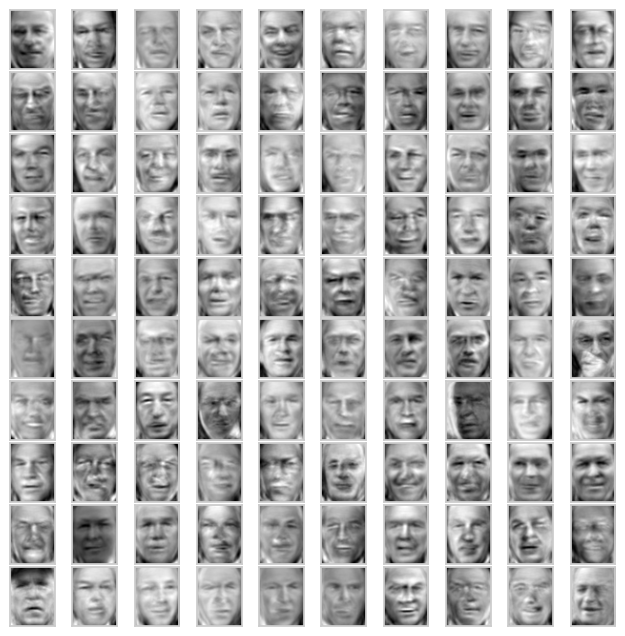

In [49]:
faces_new = pca.inverse_transform(data_new)
# show the new images
plot_faces(faces_new.reshape(-1,62, 47))

PCA+GMM is a good approach to reduce time cost.